In [1]:
%pip install keras
%pip install tensorflow
import os, datetime
from pathlib import Path


from numpy import array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, BatchNormalization, Conv1D, MaxPooling1D, Conv2D, MaxPooling2D, Dropout
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix)




In [3]:
# use of SEED for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.19.0
Keras version: 3.13.2
GPU available: True


In [4]:
def compute_metrics(y_true, y_prob, num_classes):
    y_true = np.asarray(y_true).astype(int)
    y_pred = y_prob.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Multi-class AUC: all classes present in MNIST test set, so no filtering needed
    auc = roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr',
                        labels=list(range(num_classes)))
    return {'accuracy': acc, 'f1_macro': f1, 'auc_macro_ovr': auc}, y_pred

## 2. MNIST: load and prepare data
Project spec: 50k training + 10k test. We hold out 10% of training (5,000) as a validation set for hyperparameter tuning.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (45000, 28, 28, 1) (45000,)
Validation set shape: (5000, 28, 28, 1) (5000,)
Test set shape: (10000, 28, 28, 1) (10000,)

--- Printing a few samples from the MNIST training set ---


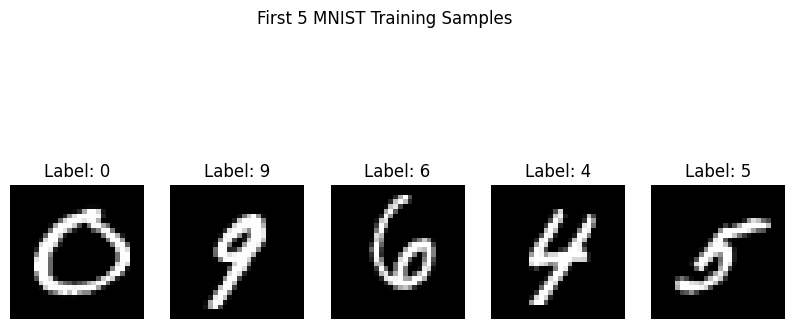

In [5]:

mnist = tf.keras.datasets.mnist

(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()


# Normalize pixel values to the range [0, 1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# Reshape for Conv2D: (samples, 28, 28, 1 )
X_train_full = X_train_full[ ..., np.newaxis] # creates new extra dimension for (batch, height, width, channels)
X_test = X_test[ ..., np.newaxis]


# Project spec: take first 50k as training pool
X_pool, y_pool = X_train_full[:50000], y_train_full[:50000]



# Split the full training set into a training set and a validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_pool, y_pool, test_size=0.1, random_state=SEED
)
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)


# print the few first image datasets to see how data looks like

print("\n--- Printing a few samples from the MNIST training set ---")
# Display the first 5 images from the MNIST training set
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.suptitle('First 5 MNIST Training Samples')
plt.show()


## 3. MNIST: DeeperCNN architecture

Same pattern as Example 2 in the lecture practice code (`Conv2D` + `MaxPooling2D` + `Flatten` + `Dense`). We add BatchNormalization and Dropout for regularization, which are standard in modern CNNs.

Architecture:
`[Conv2D-BN-ReLU] ×2 → MaxPool → [Conv2D-BN-ReLU] ×2 → MaxPool → Flatten → Dense(128)-BN-ReLU-Dropout → Dense(10, softmax)`


In [6]:
def build_deeper_cnn(dropout=0.5):
    """DeeperCNN for MNIST — Keras Sequential style."""
    model = Sequential([
        # Block 1: 28x28 -> 14x14
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 2: 14x14 -> 7x7
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Classifier head
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(10, activation='softmax')   # Softmax output (lecture, slide 52)
    ])
    return model

# Show architecture summary
demo_model = build_deeper_cnn()
demo_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

## 4. MNIST: hyperparameter tuning

Grid search over (learning rate, dropout). Each candidate trains for 5 epochs on the training subset and is evaluated on the validation set.

Choice of grid search: only have two hyperparamters to tune and trainings runs are faster

In [7]:
print('=== Tuning DeeperCNN on validation set ===')
deep_grid = []
for lr, dr in [(1e-3, 0.3), (1e-3, 0.5), (5e-4, 0.5)]:
    tf.keras.utils.set_random_seed(SEED)
    model = build_deeper_cnn(dropout=dr)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',   # Cross-Entropy
        metrics=['accuracy']
    )
    hist = model.fit(X_train, y_train, epochs=5, batch_size=128,
                     validation_data=(X_val, y_val), verbose=0)
    best_val = float(max(hist.history['val_accuracy']))
    deep_grid.append({'lr': lr, 'dropout': dr, 'val_acc': best_val})
    print(f'  lr={lr:.0e} dropout={dr}  ->  val_acc={best_val:.4f}')

best_deep = max(deep_grid, key=lambda r: r['val_acc'])
print(f'\nBest config: {best_deep}')

=== Tuning DeeperCNN on validation set ===
  lr=1e-03 dropout=0.3  ->  val_acc=0.9898
  lr=1e-03 dropout=0.5  ->  val_acc=0.9870
  lr=5e-04 dropout=0.5  ->  val_acc=0.9914

Best config: {'lr': 0.0005, 'dropout': 0.5, 'val_acc': 0.9914000034332275}


## 5. MNIST: final training on full 50k + TensorBoard

Uses TensorBoard callback just like the lecture practice code to monitor training.

In [8]:
# Load TensorBoard notebook extension

print(f'=== Final DeeperCNN on full 50k  (lr={best_deep["lr"]}, dropout={best_deep["dropout"]}) ===')
tf.keras.utils.set_random_seed(SEED)
final_model = build_deeper_cnn(dropout=best_deep['dropout'])
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_deep['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TensorBoard callback (same pattern as lecture)
logdir = os.path.join('logs', 'mnist_' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
tb_cb = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

import time
t0 = time.time()
final_hist = final_model.fit(
    X_pool, y_pool,                       # train on full 50k
    epochs=10, batch_size=128,
    validation_data=(X_test, y_test),     # test set used for monitoring only
    callbacks=[tb_cb], verbose=1
)
train_time = time.time() - t0
print(f'\nTraining completed in {train_time:.1f}s')

=== Final DeeperCNN on full 50k  (lr=0.0005, dropout=0.5) ===
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9443 - loss: 0.1915 - val_accuracy: 0.8223 - val_loss: 0.6299
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9834 - loss: 0.0562 - val_accuracy: 0.9863 - val_loss: 0.0449
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9892 - loss: 0.0384 - val_accuracy: 0.9875 - val_loss: 0.0380
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9914 - loss: 0.0290 - val_accuracy: 0.9903 - val_loss: 0.0310
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9933 - loss: 0.0226 - val_accuracy: 0.9913 - val_loss: 0.0285
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9899 - val_loss: 0.0309
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9957 - loss: 0.0150 - val_accuracy: 0.9934 - val_loss: 0.0235
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━

In [9]:
# Evaluate on the 10k test set
y_prob = final_model.predict(X_test, verbose=0)
deep_metrics, y_pred_mnist = compute_metrics(y_test, y_prob, 10)
deep_metrics['train_time_sec'] = train_time

print('=== MNIST test metrics ===')
for k, v in deep_metrics.items():
    print(f'  {k:15s}: {v:.6f}' if isinstance(v, float) else f'  {k:15s}: {v}')

=== MNIST test metrics ===
  accuracy       : 0.991100
  f1_macro       : 0.991018
  auc_macro_ovr  : 0.999961
  train_time_sec : 59.464566


In [10]:
# Launch TensorBoard
%tensorboard --logdir logs

UsageError: Line magic function `%tensorboard` not found.


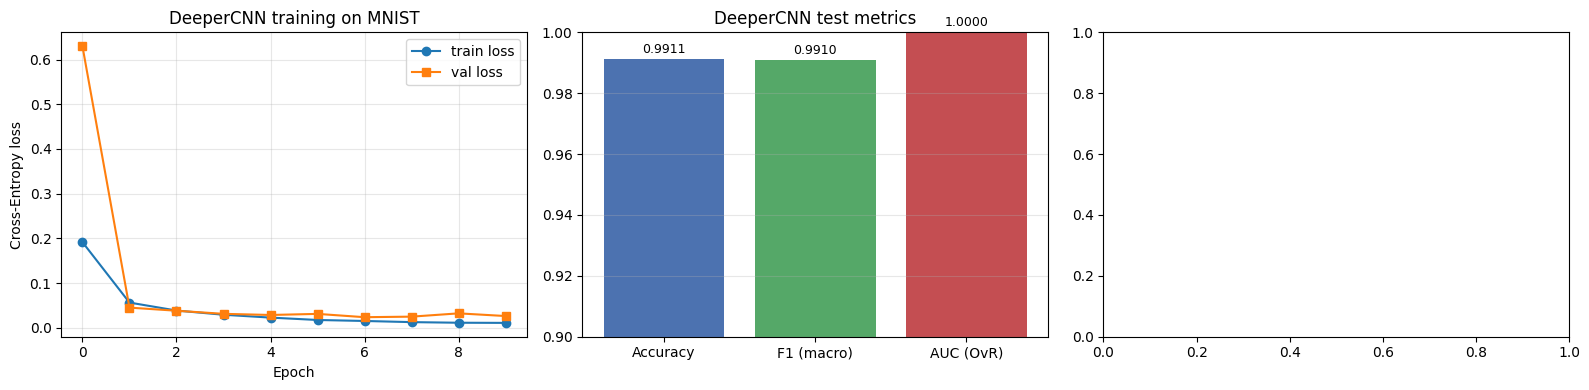

In [11]:
# Visualize MNIST results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Training curves
axes[0].plot(final_hist.history['loss'], label='train loss', marker='o')
axes[0].plot(final_hist.history['val_loss'], label='val loss', marker='s')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy loss')
axes[0].set_title('DeeperCNN training on MNIST')
axes[0].legend(); axes[0].grid(alpha=.3)

# (b) Test metrics bar chart
labels = ['Accuracy', 'F1 (macro)', 'AUC (OvR)']
vals = [deep_metrics['accuracy'], deep_metrics['f1_macro'], deep_metrics['auc_macro_ovr']]
axes[1].bar(labels, vals, color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_ylim(0.9, 1.0); axes[1].set_title('DeeperCNN test metrics')
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)
axes[1].grid(alpha=.3, axis='y')


plt.tight_layout()
plt.show()

## 6. Cho: load and prepare data

Upload `cho.txt` (from Project 1). Expected format: col 0 = gene ID, col 1 = class label, cols 2–17 = 16 expression values.

Protocol per project spec for small datasets: stratified 80/20 split, 3-fold CV tuning, 3 repeated runs with mean ± std.

In [12]:
# Upload cho.txt
try:
    from google.colab import files
    uploaded = files.upload()
    CHO_PATH = list(uploaded.keys())[0]
except Exception:
    CHO_PATH = 'cho.txt'
print('Using:', CHO_PATH)

Saving cho.txt to cho.txt
Using: cho.txt


In [13]:
def load_cho(path):
    """Standard Project-1 layout: gene_id, label, 16 features."""
    for sep in ['\t', r'\s+', ',']:
        try:
            df = pd.read_csv(path, sep=sep, header=None, engine='python')
            if df.shape[1] >= 17:
                break
        except Exception:
            continue
    else:
        raise ValueError('Could not parse Cho into >=17 cols.')
    if not np.issubdtype(df.iloc[:, -1].dtype, np.number):
        df = df.iloc[1:].reset_index(drop=True)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    labels = df.iloc[:, 1].astype(int).values
    X = df.iloc[:, 2:18].values.astype(np.float32)
    # Drop noise labels (often -1), remap to 0..K-1
    keep = labels >= 0
    X, labels = X[keep], labels[keep]
    uniq = sorted(np.unique(labels).tolist())
    remap = {v: i for i, v in enumerate(uniq)}
    y = np.array([remap[v] for v in labels], dtype=np.int64)
    print(f'Loaded Cho: X={X.shape}  classes {uniq} -> 0..{len(uniq)-1}')
    return X, y, len(uniq)

X_cho, y_cho, NUM_CLASSES = load_cho(CHO_PATH)

# Stratified 80/20 split (use same seed as your teammates!)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cho, y_cho, test_size=0.2, random_state=SEED, stratify=y_cho
)
print(f'train={len(X_tr)}  test={len(X_te)}  classes={NUM_CLASSES}')

Loaded Cho: X=(386, 16)  classes [1, 2, 3, 4, 5] -> 0..4
train=308  test=78  classes=5


## 7. Cho: Cho1DCNN architecture

Same pattern as Example 1 in the lecture practice code (`Conv1D` + `MaxPooling1D` + `Flatten` + `Dense`). Small network because dataset is small (~386 samples).

Each gene's 16 time points become a sequence of length 16 with 1 channel; 1D convolution slides a kernel-size-3 filter along the temporal axis.

In [14]:
def build_cho_1d_cnn(dropout=0.3):
    """Cho1DCNN — Keras Sequential style, following the lecture's 1D CNN example."""
    model = Sequential([
        Conv1D(filters=16, kernel_size=3, padding='same',
               activation='relu', input_shape=(16, 1)),
        BatchNormalization(),
        Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

demo = build_cho_1d_cnn()
demo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,597 (72.64 KB)

 Trainable params: 18,501 (72.27 KB)

 Non-trainable params: 96 (384.00 B)

## 8. Cho: 3-fold cross-validation tuning as given k = 3

For each (lr, dropout) combination, do 3-fold stratified CV on the training set and record the mean validation accuracy. The scaler is fit on each training fold only (no leakage).

In [15]:
def reshape_1d(X):
    """Reshape (N, 16) -> (N, 16, 1) for Conv1D input."""
    return X.reshape(X.shape[0], X.shape[1], 1).astype('float32')


print('=== 3-fold CV hyperparameter tuning ===')
K_FOLDS = 3; EPOCHS_CHO = 60; PATIENCE = 10
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

cho_grid = []
for lr, dr in [(1e-3, 0.2), (1e-3, 0.4), (5e-4, 0.2), (5e-4, 0.4)]:
    fold_accs = []
    for fold, (tri, vai) in enumerate(skf.split(X_tr, y_tr)):

        # Fit scaler on training fold ONLY
        sc = StandardScaler().fit(X_tr[tri])
        Xa = reshape_1d(sc.transform(X_tr[tri]))
        Xb = reshape_1d(sc.transform(X_tr[vai]))

        tf.keras.utils.set_random_seed(SEED + fold)
        model = build_cho_1d_cnn(dropout=dr)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        es = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                           patience=PATIENCE,
                                           restore_best_weights=True)
        hist = model.fit(Xa, y_tr[tri], epochs=EPOCHS_CHO, batch_size=16,
                         validation_data=(Xb, y_tr[vai]),
                         callbacks=[es], verbose=0)
        fold_accs.append(float(max(hist.history['val_accuracy'])))
    mean_acc = float(np.mean(fold_accs))
    cho_grid.append({'lr': lr, 'dropout': dr,
                     'fold_accs': fold_accs, 'cv_mean': mean_acc})
    print(f'  lr={lr:.0e} dr={dr}  cv_mean={mean_acc:.4f}  folds={[f"{a:.3f}" for a in fold_accs]}')

best_cho = max(cho_grid, key=lambda r: r['cv_mean'])
print(f'\nBest Cho HP: lr={best_cho["lr"]} dropout={best_cho["dropout"]} cv_acc={best_cho["cv_mean"]:.4f}')

=== 3-fold CV hyperparameter tuning ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

  lr=1e-03 dr=0.2  cv_mean=0.6688  folds=['0.680', '0.660', '0.667']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

  lr=1e-03 dr=0.4  cv_mean=0.7144  folds=['0.670', '0.709', '0.765']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

  lr=5e-04 dr=0.2  cv_mean=0.6625  folds=['0.631', '0.641', '0.716']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

  lr=5e-04 dr=0.4  cv_mean=0.7112  folds=['0.738', '0.631', '0.765']

Best Cho HP: lr=0.001 dropout=0.4 cv_acc=0.7144


## 9. Cho: 3 repeated final runs (per project spec)

Train 3 times with different seeds using the best HP, evaluate on the held-out test set, report mean ± std.

In [16]:
print('=== 3 independent runs with best HP ===')
cho_runs, cho_ys = [], []
for rep in range(3):
    # Scaler fit on full training set only
    sc = StandardScaler().fit(X_tr)
    Xa = reshape_1d(sc.transform(X_tr))
    Xb = reshape_1d(sc.transform(X_te))

    tf.keras.utils.set_random_seed(SEED + 100 * rep)
    model = build_cho_1d_cnn(dropout=best_cho['dropout'])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_cho['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model.fit(Xa, y_tr, epochs=EPOCHS_CHO, batch_size=16, verbose=0)

    y_prob = model.predict(Xb, verbose=0)
    metrics, y_pred = compute_metrics(y_te, y_prob, NUM_CLASSES)
    cho_runs.append(metrics)
    cho_ys.append((y_te, y_pred))
    print(f'  run {rep+1}: acc={metrics["accuracy"]:.4f}  f1={metrics["f1_macro"]:.4f}  auc={metrics["auc_macro_ovr"]:.4f}')

# Aggregate mean ± std
cho_agg = {}
for k in ['accuracy', 'f1_macro', 'auc_macro_ovr']:
    vals = [r[k] for r in cho_runs if not np.isnan(r[k])]
    cho_agg[k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}

print('\nAggregated (mean ± std):')
for k, v in cho_agg.items():
    print(f'  {k:15s}: {v["mean"]:.4f} ± {v["std"]:.4f}')

=== 3 independent runs with best HP ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  run 1: acc=0.7821  f1=0.7908  auc=0.9350


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  run 2: acc=0.8205  f1=0.8113  auc=0.9524
  run 3: acc=0.7821  f1=0.7797  auc=0.9362

Aggregated (mean ± std):
  accuracy       : 0.7949 ± 0.0181
  f1_macro       : 0.7940 ± 0.0131
  auc_macro_ovr  : 0.9412 ± 0.0079


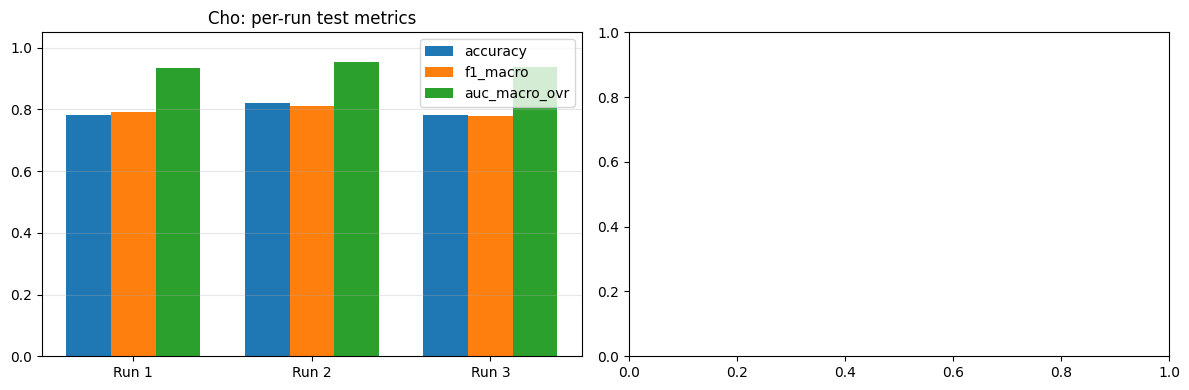

In [17]:
# Visualize Cho results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Per-run metrics
metric_names = ['accuracy', 'f1_macro', 'auc_macro_ovr']
runs_arr = np.array([[r[k] for k in metric_names] for r in cho_runs])
x = np.arange(3); w = 0.25
for i, name in enumerate(metric_names):
    axes[0].bar(x + (i-1)*w, runs_arr[:, i], w, label=name)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'Run {i+1}' for i in range(3)])
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(alpha=.3, axis='y')
axes[0].set_title('Cho: per-run test metrics')

plt.tight_layout()
plt.show()

## 10. Final Summary

In [18]:
print('=' * 60)
print('FINAL RESULTS')
print('=' * 60)

print('\nMNIST — DeeperCNN (single run on 10k test set):')
print(f"  accuracy = {deep_metrics['accuracy']:.4f}")
print(f"  f1_macro = {deep_metrics['f1_macro']:.4f}")
print(f"  auc_ovr  = {deep_metrics['auc_macro_ovr']:.4f}")
print(f"  best HP  : lr={best_deep['lr']}  dropout={best_deep['dropout']}")
print(f"  train time: {deep_metrics['train_time_sec']:.1f}s")

print('\nCho — Cho1DCNN (mean ± std over 3 runs):')
print(f"  accuracy = {cho_agg['accuracy']['mean']:.4f} ± {cho_agg['accuracy']['std']:.4f}")
print(f"  f1_macro = {cho_agg['f1_macro']['mean']:.4f} ± {cho_agg['f1_macro']['std']:.4f}")
print(f"  auc_ovr  = {cho_agg['auc_macro_ovr']['mean']:.4f} ± {cho_agg['auc_macro_ovr']['std']:.4f}")
print(f"  best HP  : lr={best_cho['lr']}  dropout={best_cho['dropout']}")

# Save everything
all_results = {
    'mnist_deeper_cnn': {
        'best_hp': best_deep,
        'tune_grid': deep_grid,
        'test_metrics': deep_metrics,
    },
    'cho_1d_cnn': {
        'best_hp': {k: best_cho[k] for k in ['lr', 'dropout', 'cv_mean']},
        'cv_grid': cho_grid,
        'runs': cho_runs,
        'aggregated': cho_agg,
        'n_train': int(len(X_tr)), 'n_test': int(len(X_te)),
        'num_classes': int(NUM_CLASSES),
    },
}


FINAL RESULTS

MNIST — DeeperCNN (single run on 10k test set):
  accuracy = 0.9911
  f1_macro = 0.9910
  auc_ovr  = 1.0000
  best HP  : lr=0.0005  dropout=0.5
  train time: 59.5s

Cho — Cho1DCNN (mean ± std over 3 runs):
  accuracy = 0.7949 ± 0.0181
  f1_macro = 0.7940 ± 0.0131
  auc_ovr  = 0.9412 ± 0.0079
  best HP  : lr=0.001  dropout=0.4
